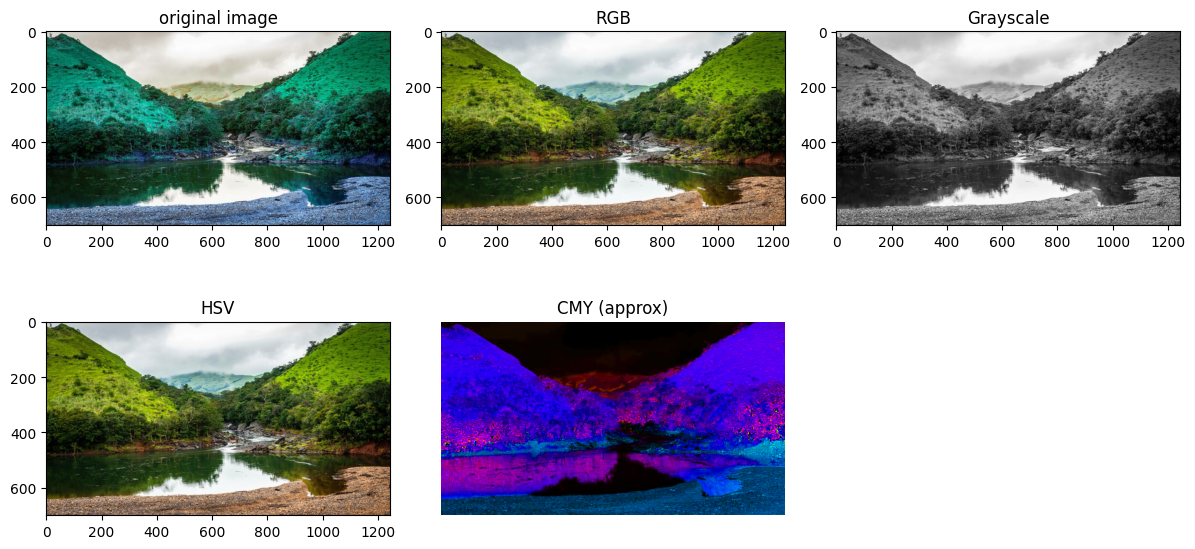

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('sample-image.jpg')

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

bgr = img.astype(float) / 255

K = 1 - np.max(bgr, axis=2)
C = (1 - bgr[..., 2] - K) / (1 - K + 1e-5)
M = (1 - bgr[..., 1] - K) / (1 - K + 1e-5)
Y = (1 - bgr[..., 0] - K) / (1 - K + 1e-5)
CMYK = np.stack((C, M, Y, K), axis=-1)

titles = ["original image", 'RGB', 'Grayscale', 'HSV', 'CMY (approx)']
images = [img, img_rgb, gray, cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB), CMYK[..., :3]]

plt.figure(figsize=(12, 6))
for i in range(5):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], cmap='gray' if titles[i] == 'Grayscale' else None)
    plt.title(titles[i])
plt.axis('off')
plt.tight_layout()
plt.show()